# 60 - The `nn.Conv2d` Layer

**Section:** Convolution and transformations | **Prereqs:** `Convolution and transformations/Convolutions_in_Code.ipynb` | **Next:** `Convolution and transformations/CodeChallenge_Choosing_Parameters.ipynb`

`nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)` - five
numbers that decide everything about a convolutional layer.

| Argument | Meaning |
|---|---|
| `in_channels` | depth of the input (3 for RGB, 1 for greyscale, or the previous layer's `out_channels`) |
| `out_channels` | how many kernels to learn - each produces one feature map |
| `kernel_size` | the kernel's height and width (3 and 5 are near-universal) |
| `stride` | how far the kernel moves per step; 2 halves the output size |
| `padding` | zeros added around the border; `padding=kernel_size//2` keeps the size |

**The weight shape is `(out_channels, in_channels, kH, kW)`.** Each of the
`out_channels` kernels spans *all* input channels - it is a 3-D block, not a flat
square. That is why a conv layer can combine colour information rather than
processing each channel separately.

**Parameter count:** `out * in * kH * kW + out`. For (3 -> 15, 5x5) that is 1140
parameters - independent of image size, which is exactly why CNNs scale to large
images where fully connected layers cannot.

**Untrained kernels are noise.** The visualisations here show random
initialisation, not learned features; `CNNs/Examining_Feature_Maps.ipynb` shows
what they become after training.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

!pip install torchvision
import torchvision
import torchvision.transforms as transforms

In [4]:
# MNIST via torchvision. Not used further here - the notebook works with random
# tensors so the shapes stay easy to follow.
transform = transforms.ToTensor()

# Load the training dataset
mnist_trainset = torchvision.datasets.MNIST(
    root='./data',      # Directory to save the data
    train=True,         # Request the training subset
    download=True,      # Download the data if not already present
    transform=transform # Apply the transform
)

# Load the test dataset
mnist_testset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 57.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.63MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.27MB/s]


In [9]:
mnist_trainset.targets.shape , mnist_trainset.data.shape

(torch.Size([60000]), torch.Size([60000, 28, 28]))

In [14]:
type(nn.Conv2d(2,2,2))

torch.nn.modules.conv.Conv2d

In [19]:
# The five arguments spelled out. Note out_channels = 15 means 15 SEPARATE
# kernels, each producing its own feature map - not a 15x15 kernel.
in_chans = 3 # RGB
out_chans = 15 # Each kernal has a its own output channel (feature map), so we have 15 kernals
kernal_size = 5 # Kernal size not number of kernals (5 x 5)
stride = 1
padding = 0

c  = nn.Conv2d(in_chans, out_chans, kernal_size , stride, padding)

In [20]:
# printing the layer shows the configuration it will use.
print(c)

Conv2d(3, 15, kernel_size=(5, 5), stride=(1, 1))


In [21]:
# Weight shape (15, 3, 5, 5) = (out_channels, in_channels, kH, kW), plus 15
# biases (one per output channel).
# Each kernel spans all 3 input channels, so it is a 3x5x5 block.
# Total parameters: 15*3*5*5 + 15 = 1140, and that number does not change if
# the image gets bigger.
c.weight.shape , c.bias.shape

(torch.Size([15, 3, 5, 5]), torch.Size([15]))

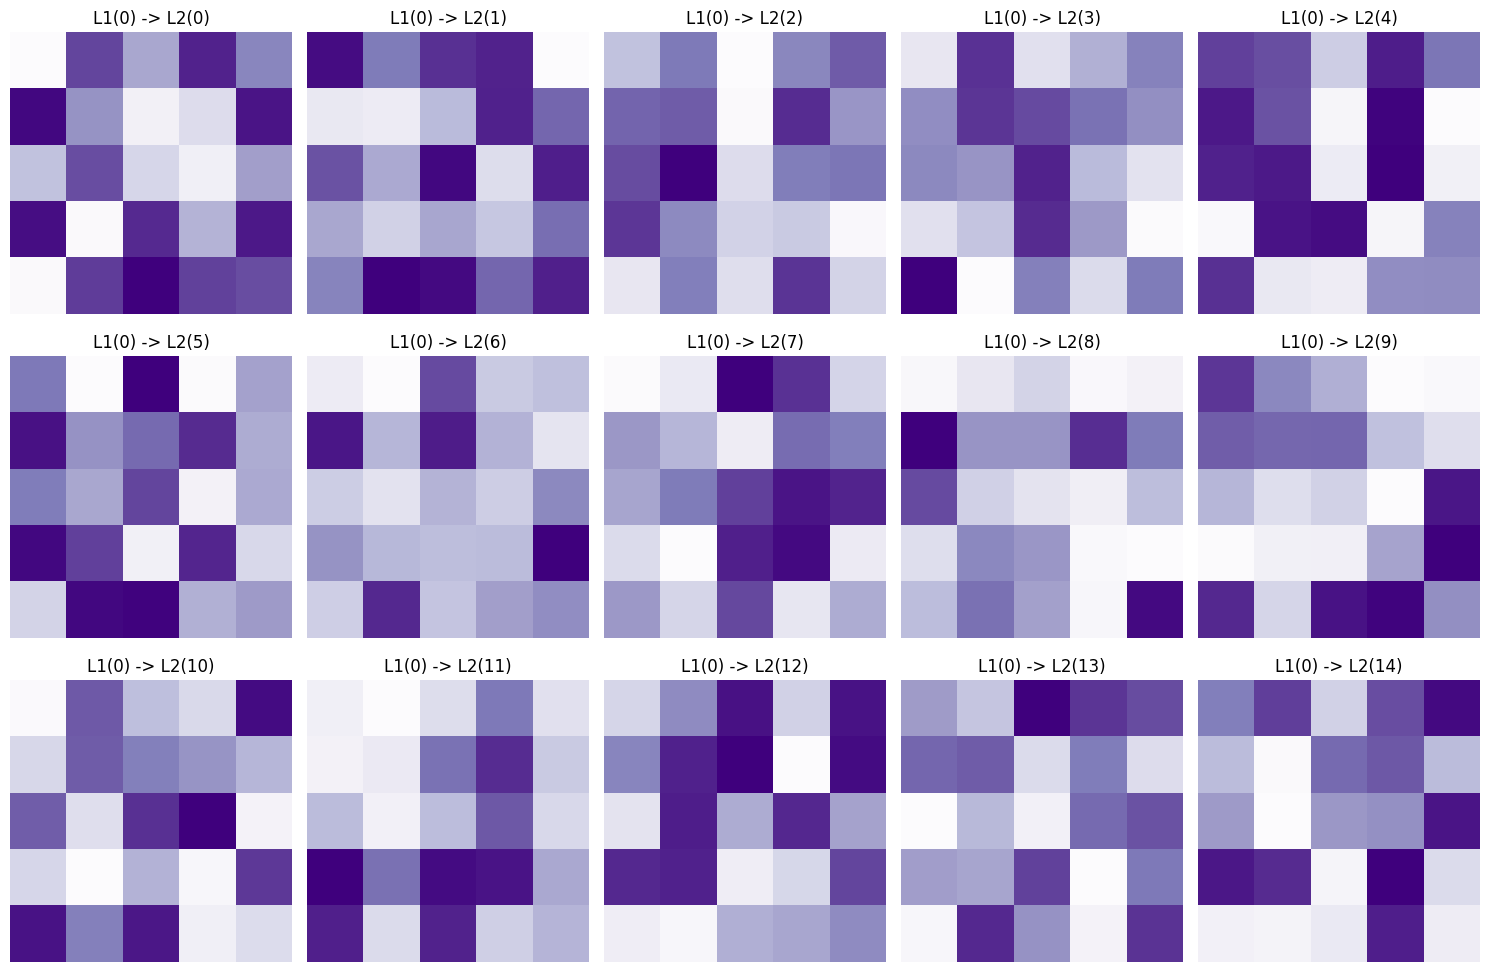

In [30]:
# The 15 kernels' first input channel, visualised.
# This is an UNTRAINED layer, so they are random noise. After training on real
# images the first-layer kernels look like the edge detectors from the previous
# notebook - the network rediscovers them on its own.
fig, ax = plt.subplots(3,5, figsize=(15,10))

for i,ax in enumerate(ax.flatten()):
  ax.imshow(torch.squeeze(c.weight[i,0,:,:]).detach(),cmap='Purples')
  ax.set_title('L1(0) -> L2(%s)' %i)
  ax.axis('off')

plt.tight_layout();

## Implementing Conv

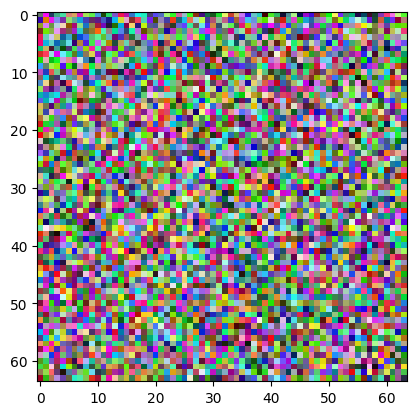

In [35]:
# A random RGB image in PyTorch layout (1,3,64,64).
# .permute() reorders axes for matplotlib, which wants (H, W, C).
# permute vs view: permute REORDERS existing axes, view REINTERPRETS the memory
# layout. Using view here would scramble the image.
image_size = (1,3,64,64) # (N, channels, width ,height)

img = torch.rand(image_size)

img_np = img.permute(2,3,1,0).numpy() # Matplotlib is expecting (width, height, channels, N)

plt.imshow(np.squeeze(img_np));



In [37]:
np.squeeze(img_np).shape , img_np.shape

((64, 64, 3), (64, 64, 3, 1))

In [44]:
# Applying the layer: (1,3,64,64) -> (1,15,60,60).
# 3 channels in, 15 out (one per kernel), and 64 -> 60 because a 5x5 kernel with
# no padding loses 2 pixels on each side.
print("Now we convolve")

output = c(img)
output.shape

Now we convolve


torch.Size([1, 15, 60, 60])

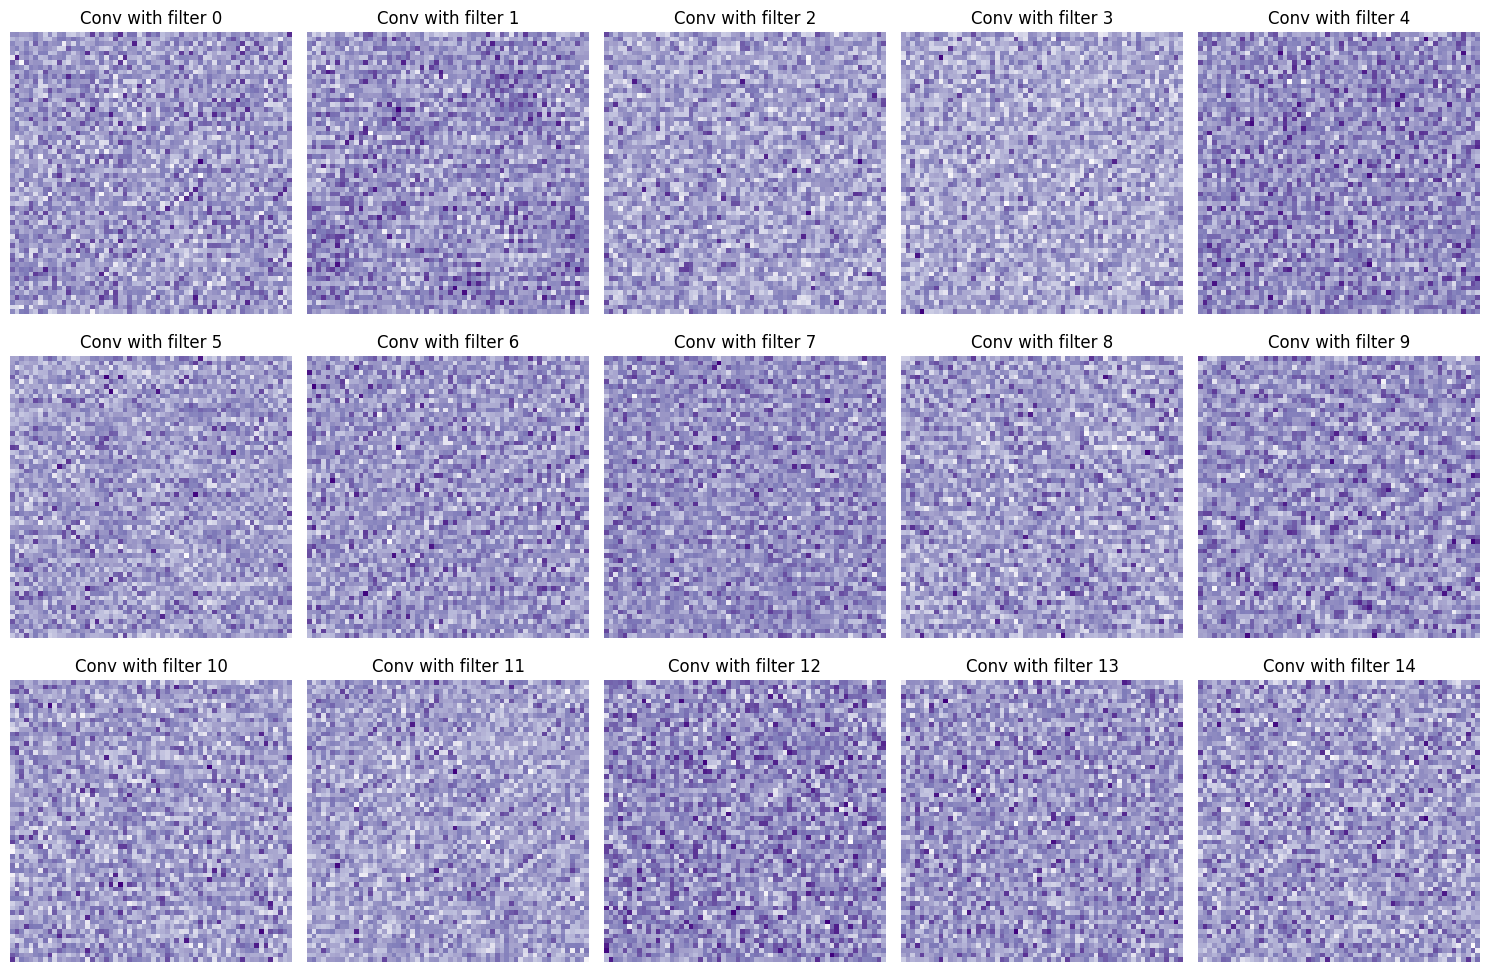

In [46]:
# The 15 feature maps. With random kernels they are 15 different random
# projections; after training each would respond to a different visual pattern.

fig, ax = plt.subplots(3,5, figsize=(15,10))

for i,ax in enumerate(ax.flatten()):

  ax.imshow(torch.squeeze(torch.squeeze(output[0,i,:,:])).detach(),cmap='Purples')
  ax.set_title('Conv with filter %s' %i)
  ax.axis('off')

plt.tight_layout();